In [1]:
!pip install kagglehub -q

In [2]:
import kagglehub

path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")
print("Dataset downloaded to:", path)

import os
print(os.listdir(path))

Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.
Dataset downloaded to: /kaggle/input/customer-segmentation-tutorial-in-python
['Mall_Customers.csv']


In [3]:
import pandas as pd
import numpy as np

csv_path = f"{path}/Mall_Customers.csv"   # if using kagglehub
# csv_path = "Mall_Customers.csv"          # if manually uploaded

df = pd.read_csv(csv_path)
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Categorical features: ['Gender']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
df.describe(include='all')

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200,200.000000,200.000000,200.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,112,NaN,NaN,NaN
mean,100.500000,NaN,38.850000,60.560000,50.200000
std,57.879185,NaN,13.969007,26.264721,25.823522
min,1.000000,NaN,18.000000,15.000000,1.000000
25%,50.750000,NaN,28.750000,41.500000,34.750000
50%,100.500000,NaN,36.000000,61.500000,50.000000
75%,150.250000,NaN,49.000000,78.000000,73.000000


In [8]:
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [10]:
df_clean = df.drop(columns=['CustomerID'])
df_clean.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [11]:
df_clean['Gender'] = df_clean['Gender'].map({'Male': 0, 'Female': 1})
df_clean.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


In [12]:
from sklearn.preprocessing import StandardScaler

features_to_scale = ['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

scaler = StandardScaler()
scaled_array = scaler.fit_transform(df_clean[features_to_scale])
scaled_df = pd.DataFrame(scaled_array, columns=features_to_scale)

scaled_df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,-1.128152,-1.424569,-1.738999,-0.434801
1,-1.128152,-1.281035,-1.738999,1.195704
2,0.886405,-1.352802,-1.700830,-1.715913
3,0.886405,-1.137502,-1.700830,1.040418
4,0.886405,-0.563369,-1.662660,-0.395980


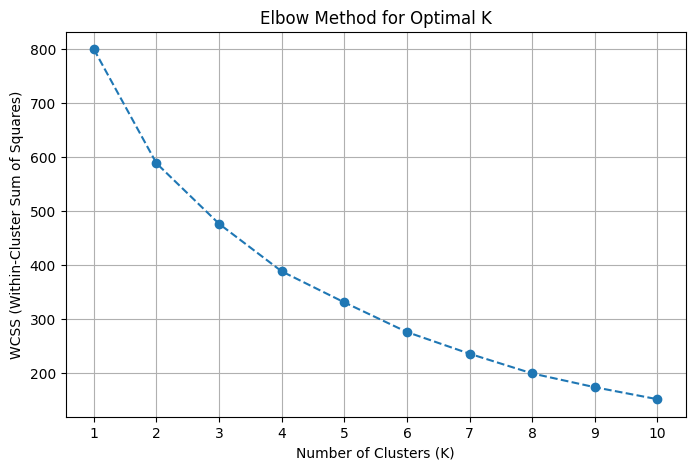

In [13]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans_temp.fit(scaled_df)
    wcss.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(K_range)
plt.grid(True)
plt.savefig('elbow_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
optimal_k = 5   # adjust based on where the elbow bends in your plot

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(scaled_df)

df_clean['Cluster'] = cluster_labels
df_clean.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,0,19,15,39,3
1,0,21,15,81,3
2,1,20,16,6,3
3,1,23,16,77,3
4,1,31,17,40,3


In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_df)

df_clean['PCA1'] = pca_components[:, 0]
df_clean['PCA2'] = pca_components[:, 1]

print("Explained variance ratio per component:", pca.explained_variance_ratio_)
print("Total variance explained by 2 components:", sum(pca.explained_variance_ratio_))

df_clean.head()

Explained variance ratio per component: [0.33690046 0.26230645]
Total variance explained by 2 components: 0.5992069019819846


,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,PCA1,PCA2
0,0,19,15,39,3,-0.406383,-0.520714
1,0,21,15,81,3,-1.427673,-0.367310
2,1,20,16,6,3,0.050761,-1.894068
3,1,23,16,77,3,-1.694513,-1.631908
4,1,31,17,40,3,-0.313108,-1.810483


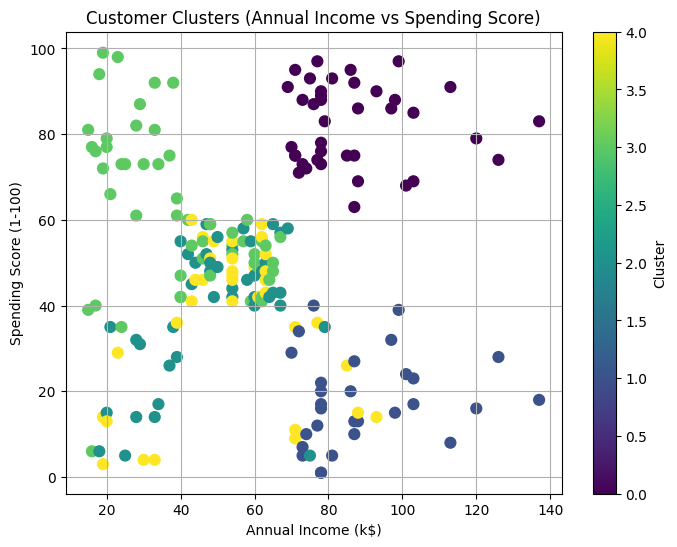

In [16]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df_clean['Annual Income (k$)'], df_clean['Spending Score (1-100)'],
                       c=df_clean['Cluster'], cmap='viridis', s=60)
plt.title('Customer Clusters (Annual Income vs Spending Score)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.savefig('cluster_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

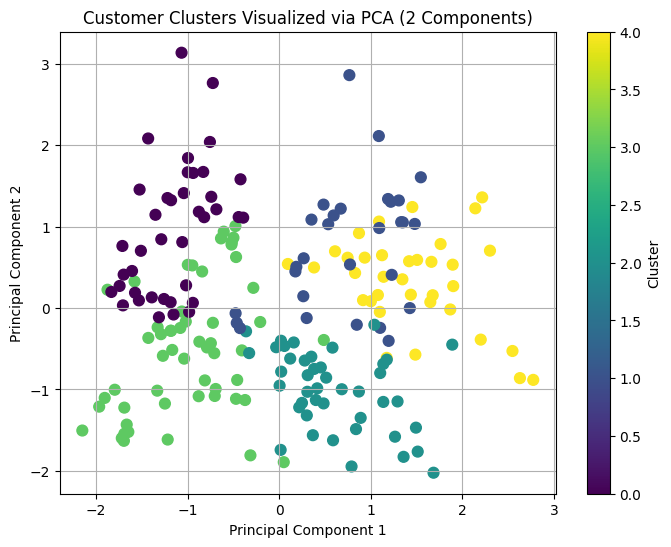

In [17]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df_clean['PCA1'], df_clean['PCA2'],
                       c=df_clean['Cluster'], cmap='viridis', s=60)
plt.title('Customer Clusters Visualized via PCA (2 Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.savefig('pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
cluster_summary = df_clean.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
print(cluster_summary)

               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        32.692308           86.538462               82.128205
1        36.482759           89.517241               18.000000
2        49.813953           49.232558               40.069767
3        24.907407           39.722222               61.203704
4        55.714286           53.685714               36.771429
